<a href="https://colab.research.google.com/github/eswardn12/Data-Science-60-Day-Portfolio/blob/main/Day3_Lead_Scoring_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3 — Lead Scoring: Hands-On Notebook


This notebook operationalizes Day 3's concepts through three case studies on synthetic seller-lead data:

1. **(Deep) WOE/IV Scorecard vs Raw Logistic Regression**
2. **(Deep) Calibrated GBM with Reliability Diagrams** — Platt Scaling vs Isotonic Regression
3. **(Lighter) KS Statistic & Decile/Gains Table Generator**

Plus **Named Extensions** for further independent practice.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve
from xgboost import XGBClassifier

np.random.seed(11)
plt.rcParams['figure.figsize'] = (10, 5)
EBAY_BLUE = '#0064D2'; EBAY_RED = '#E53238'; EBAY_GOLD = '#F5AF02'; EBAY_GREEN = '#86B817'
print('Environment ready.')


Environment ready.


---
## Shared Dataset — Synthetic Seller Lead / Application Data
**Business framing:** A prospective seller application is scored for likelihood of reaching first-listing within 30 days (Day 3 report Section 3's running example). Label `converted` = 1 if the seller lists within the window.


In [ ]:
n = 8000
df = pd.DataFrame({
    'business_registration_verified': np.random.binomial(1, 0.62, n),
    'years_in_business': np.random.exponential(4, n).clip(0, 40),
    'time_to_complete_application_min': np.random.exponential(25, n).clip(1, 300),
    'onboarding_steps_completed': np.random.randint(0, 6, n),
    'acquisition_channel': np.random.choice(['referral','paid','organic','bd_sourced'], n, p=[0.2,0.3,0.35,0.15]),
    'declared_category_competitiveness': np.random.uniform(0,1,n),
    'estimated_catalog_size': np.random.exponential(30, n).clip(0, 500),
})
channel_effect = df['acquisition_channel'].map({'referral':0.9,'bd_sourced':0.7,'organic':0.0,'paid':-0.5})

def z(s): return (s - s.mean())/s.std()

logit = (
    1.4*df['business_registration_verified']
    + 0.6*z(df['years_in_business'])
    - 0.7*z(df['time_to_complete_application_min'])
    + 0.8*z(df['onboarding_steps_completed'])
    + 0.5*channel_effect
    - 0.3*z(df['declared_category_competitiveness'])
    + 0.6*z(df['estimated_catalog_size'])
    - 1.7
)
prob = 1/(1+np.exp(-logit))
df['converted'] = np.random.binomial(1, prob.clip(0.02,0.95))
print(f'Shape: {df.shape}')
print(f'Conversion rate: {df.converted.mean():.2%}')
df.head()


Shape: (8000, 8)
Conversion rate: 36.86%


,business_registration_verified,years_in_business,time_to_complete_application_min,onboarding_steps_completed,acquisition_channel,declared_category_competitiveness,estimated_catalog_size,converted
0,1,2.226380,5.333206,4,organic,0.726305,3.125761,1
1,1,1.030268,8.337818,3,paid,0.833097,161.379182,1
2,1,3.210465,54.010127,5,paid,0.355316,7.014662,0
3,0,14.115395,3.710343,4,referral,0.412191,52.407004,1
4,1,0.991967,3.813192,2,paid,0.704012,6.492840,1


---
## Case Study 1 (Deep) — WOE/IV Scorecard vs Raw Logistic Regression
**Business framing:** Building a Weight-of-Evidence transformed scorecard (Day 3 report Section 4), ranking every candidate feature by Information Value before modeling, and comparing against an untransformed Logistic Regression baseline.


In [ ]:
# 1.1 A reusable WOE / IV function (works for categorical or binned-continuous features)
def woe_iv(data, feature, target, bins=5, is_categorical=False):
    d = data[[feature, target]].copy()
    if not is_categorical:
        d['bin'] = pd.qcut(d[feature], q=bins, duplicates='drop')
    else:
        d['bin'] = d[feature]
    grp = d.groupby('bin', observed=True)[target].agg(['sum', 'count'])
    grp.columns = ['good', 'count']
    grp['bad'] = grp['count'] - grp['good']
    total_good, total_bad = grp['good'].sum(), grp['bad'].sum()
    grp['pct_good'] = grp['good'] / total_good
    grp['pct_bad'] = grp['bad'] / total_bad
    grp['woe'] = np.log((grp['pct_good'] + 1e-6) / (grp['pct_bad'] + 1e-6))
    grp['iv_contribution'] = (grp['pct_good'] - grp['pct_bad']) * grp['woe']
    return grp, grp['iv_contribution'].sum()

# 1.2 Compute IV for every candidate feature to triage before modeling
candidates = [
    ('business_registration_verified', True),
    ('years_in_business', False),
    ('time_to_complete_application_min', False),
    ('onboarding_steps_completed', False),
    ('acquisition_channel', True),
    ('declared_category_competitiveness', False),
    ('estimated_catalog_size', False),
]
iv_summary = []
for feat, is_cat in candidates:
    _, iv = woe_iv(df, feat, 'converted', is_categorical=is_cat)
    iv_summary.append({'feature': feat, 'IV': round(iv, 4)})

iv_df = pd.DataFrame(iv_summary).sort_values('IV', ascending=False).reset_index(drop=True)
iv_df['strength'] = pd.cut(iv_df['IV'], bins=[-1,0.02,0.10,0.30,0.50,99],
                            labels=['Not useful','Weak','Medium','Strong','Suspicious'])
iv_df


,feature,IV,strength
0,onboarding_steps_completed,0.3781,Strong
1,business_registration_verified,0.1973,Medium
2,years_in_business,0.1669,Medium
3,time_to_complete_application_min,0.1550,Medium
4,estimated_catalog_size,0.1468,Medium
5,declared_category_competitiveness,0.0466,Weak
6,acquisition_channel,0.0311,Weak


In [ ]:
# 1.3 Detailed WOE table for the strongest feature
top_feature, top_is_cat = 'business_registration_verified', True
grp, iv = woe_iv(df, top_feature, 'converted', is_categorical=top_is_cat)
print(f'IV for {top_feature}: {iv:.4f}')
grp[['good','bad','pct_good','pct_bad','woe']].round(4)


IV for business_registration_verified: 0.1973


,good,bad,pct_good,pct_bad,woe
bin,,,,,
0,719,2288,0.2438,0.453,-0.6194
1,2230,2763,0.7562,0.547,0.3238


In [ ]:
# 1.4 Build WOE-transformed feature set, fit scorecard (Logistic Regression on WOE values)
def woe_transform(data, feature, grp_table, is_categorical=False, bins=5):
    d = data.copy()
    if not is_categorical:
        d['_bin'] = pd.qcut(d[feature], q=bins, duplicates='drop')
    else:
        d['_bin'] = d[feature]
    woe_map = grp_table['woe'].to_dict()
    return d['_bin'].map(woe_map).astype(float)

woe_features = pd.DataFrame(index=df.index)
for feat, is_cat in candidates:
    grp_feat, _ = woe_iv(df, feat, 'converted', is_categorical=is_cat)
    woe_features[feat + '_woe'] = woe_transform(df, feat, grp_feat, is_categorical=is_cat)

y = df['converted']
Xw_train, Xw_test, yw_train, yw_test = train_test_split(woe_features, y, test_size=0.3, stratify=y, random_state=42)

scorecard = LogisticRegression().fit(Xw_train, yw_train)
scorecard_probs = scorecard.predict_proba(Xw_test)[:, 1]
print(f'WOE Scorecard AUC: {roc_auc_score(yw_test, scorecard_probs):.4f}')

# Compare against a raw (untransformed, one-hot for categoricals) Logistic Regression baseline
X_raw = df.drop(columns=['converted','acquisition_channel'])
X_raw = pd.concat([X_raw, pd.get_dummies(df['acquisition_channel'], prefix='chan', drop_first=True)], axis=1)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_raw, y, test_size=0.3, stratify=y, random_state=42)
raw_lr = LogisticRegression(max_iter=1000).fit(Xr_train, yr_train)
raw_probs = raw_lr.predict_proba(Xr_test)[:, 1]
print(f'Raw Logistic Regression AUC: {roc_auc_score(yr_test, raw_probs):.4f}')


WOE Scorecard AUC: 0.8097


Raw Logistic Regression AUC: 0.8216


**Interpretation:** The WOE scorecard's coefficients are directly interpretable as points (each coefficient × its WOE value contributes additively to the log-odds), giving Sales a traceable, auditable score — exactly the explainability property Section 4.1 of the report argues still matters even when a GBM (Case Study 2) achieves higher raw discrimination.


---
## Case Study 2 (Deep) — Calibrated GBM with Reliability Diagrams
**Business framing:** Demonstrating that a GBM's raw probability output is frequently miscalibrated, then fixing it with Isotonic Regression — operationalizing Day 3 report Section 5.


In [ ]:
# 2.1 Three-way split: train / calibration / test (calibration MUST be a separate holdout, never the training set)
X_train, X_temp, y_train, y_temp = train_test_split(X_raw, y, test_size=0.4, stratify=y, random_state=42)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Deliberately flexible/overfit-prone settings to make the miscalibration visible for teaching purposes
xgbm = XGBClassifier(n_estimators=600, max_depth=8, learning_rate=0.15,
                      min_child_weight=1, subsample=1.0, colsample_bytree=1.0,
                      eval_metric='logloss', random_state=42).fit(X_train, y_train)

raw_probs_test = xgbm.predict_proba(X_test)[:, 1]
raw_probs_calib = xgbm.predict_proba(X_calib)[:, 1]

print(f'AUC (test): {roc_auc_score(y_test, raw_probs_test):.4f}')
print(f'Brier Score, raw (test, lower=better): {brier_score_loss(y_test, raw_probs_test):.4f}')


AUC (test): 0.7684
Brier Score, raw (test, lower=better): 0.2189


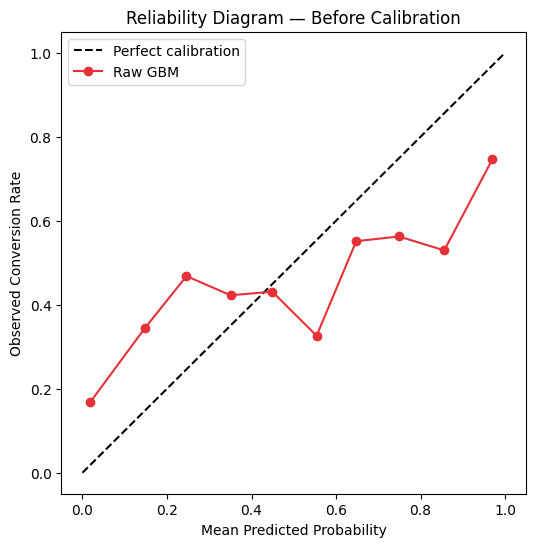

In [ ]:
# 2.2 Reliability diagram BEFORE calibration
frac_pos, mean_pred = calibration_curve(y_test, raw_probs_test, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1],'k--', label='Perfect calibration')
plt.plot(mean_pred, frac_pos, marker='o', color=EBAY_RED, label='Raw GBM')
plt.xlabel('Mean Predicted Probability'); plt.ylabel('Observed Conversion Rate')
plt.title('Reliability Diagram — Before Calibration')
plt.legend(); plt.show()


Brier Score, calibrated (test): 0.1858
AUC unchanged by calibration (rank-order preserved): 0.7672


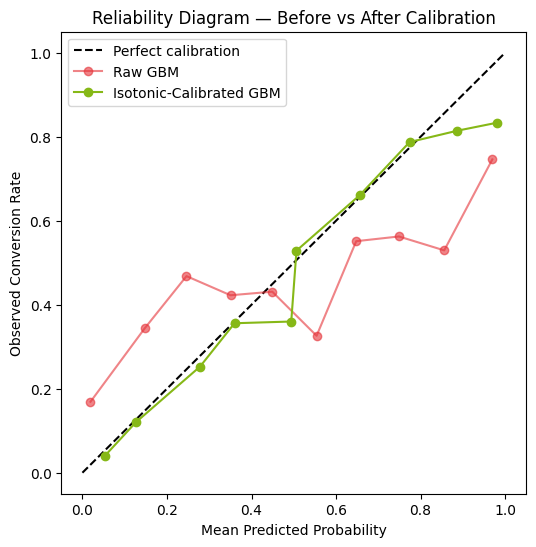

In [ ]:
# 2.3 Fit Isotonic Regression on the SEPARATE calibration set, apply to test set
iso = IsotonicRegression(out_of_bounds='clip').fit(raw_probs_calib, y_calib)
cal_probs_test = iso.predict(raw_probs_test)

print(f'Brier Score, calibrated (test): {brier_score_loss(y_test, cal_probs_test):.4f}')
print(f'AUC unchanged by calibration (rank-order preserved): {roc_auc_score(y_test, cal_probs_test):.4f}')

frac_pos_cal, mean_pred_cal = calibration_curve(y_test, cal_probs_test, n_bins=10)
plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1],'k--', label='Perfect calibration')
plt.plot(mean_pred, frac_pos, marker='o', color=EBAY_RED, label='Raw GBM', alpha=0.6)
plt.plot(mean_pred_cal, frac_pos_cal, marker='o', color=EBAY_GREEN, label='Isotonic-Calibrated GBM')
plt.xlabel('Mean Predicted Probability'); plt.ylabel('Observed Conversion Rate')
plt.title('Reliability Diagram — Before vs After Calibration')
plt.legend(); plt.show()


**Key teaching point:** AUC-ROC is identical before and after calibration (Isotonic Regression is monotonic, so rank-order — and therefore discrimination — is preserved), but the Brier Score improves and the reliability curve visibly tightens to the diagonal. This is the concrete proof that calibration and discrimination are separate properties, exactly as argued in Day 3 report Section 5.1 — a model doesn't need to change *which* leads it ranks highest to become dramatically more trustworthy in *what number* it assigns them.


---
## Case Study 3 (Lighter) — KS Statistic & Decile/Gains Table Generator
**Business framing:** The single artifact most likely to appear in an actual Sales/BD business review (Day 3 report Section 8.2) — reusable for any scored lead dataset going forward.


In [ ]:
# 3.1 KS statistic function
def ks_statistic(y_true, probs):
    d = pd.DataFrame({'y': y_true, 'p': probs}).sort_values('p', ascending=False).reset_index(drop=True)
    d['cum_good'] = (d['y'] == 1).cumsum() / (d['y'] == 1).sum()
    d['cum_bad'] = (d['y'] == 0).cumsum() / (d['y'] == 0).sum()
    d['ks'] = (d['cum_good'] - d['cum_bad']).abs()
    return d['ks'].max() * 100, d

ks_value, ks_table = ks_statistic(y_test.values, cal_probs_test)
print(f'KS Statistic: {ks_value:.1f}')


KS Statistic: 40.9


In [ ]:
# 3.2 Decile / Gains table generator — the artifact for the Sales business review
def decile_gains_table(y_true, probs, n_deciles=10):
    d = pd.DataFrame({'y': y_true, 'score': probs})
    d['decile'] = pd.qcut(d['score'], q=n_deciles, labels=False, duplicates='drop')
    d['decile'] = n_deciles - d['decile']  # decile 1 = highest scores

    summary = d.groupby('decile').agg(
        avg_score=('score', 'mean'),
        n_leads=('y', 'count'),
        n_converted=('y', 'sum'),
    ).sort_index()
    summary['conversion_rate'] = (summary['n_converted'] / summary['n_leads'])
    summary['cum_converted'] = summary['n_converted'].cumsum()
    summary['cum_pct_of_all_converters'] = summary['cum_converted'] / summary['n_converted'].sum()
    return summary.round(3)

gains = decile_gains_table(y_test.values, cal_probs_test)
gains


,avg_score,n_leads,n_converted,conversion_rate,cum_converted,cum_pct_of_all_converters
decile,,,,,,
2,0.848,123,99,0.805,99,0.168
3,0.646,189,122,0.646,221,0.375
4,0.504,159,85,0.535,306,0.519
5,0.490,52,18,0.346,324,0.549
6,0.383,327,136,0.416,460,0.780
7,0.319,188,48,0.255,508,0.861
8,0.260,222,50,0.225,558,0.946
9,0.125,99,12,0.121,570,0.966
10,0.082,241,20,0.083,590,1.000


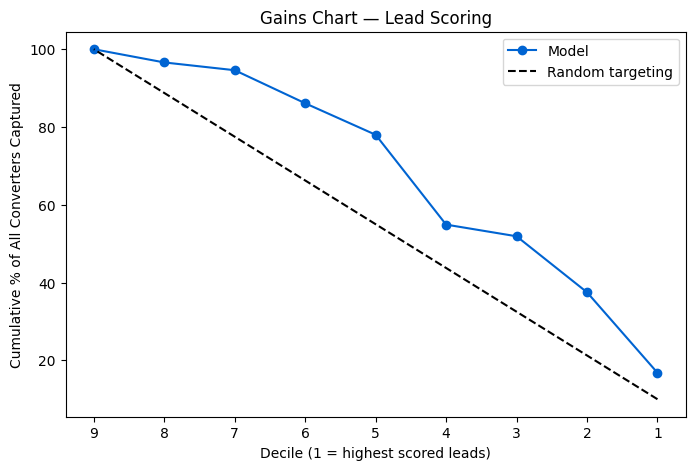

If BD can only work the top 3 deciles, they would still capture 38% of all eventual conversions.


In [ ]:
# 3.3 Visualize the gains curve — the chart that answers "how many wins if we only call our best slice"
plt.figure(figsize=(8,5))
plt.plot(range(1, len(gains)+1), gains['cum_pct_of_all_converters']*100, marker='o', color=EBAY_BLUE, label='Model')
plt.plot([1, len(gains)], [10, 100], 'k--', label='Random targeting')
plt.xlabel('Decile (1 = highest scored leads)'); plt.ylabel('Cumulative % of All Converters Captured')
plt.title('Gains Chart — Lead Scoring')
plt.legend(); plt.gca().invert_xaxis()
plt.show()

print(f"If BD can only work the top 3 deciles, they would still capture "
      f"{gains.loc[3,'cum_pct_of_all_converters']:.0%} of all eventual conversions.")


**This is the table and chart to walk into a Sales/BD business review with** — it answers a capacity-constrained staffing question directly, which is exactly what Section 9 of the Day 3 report argues should replace a lone AUC or KS number in executive communication.


---
## Named Extensions (Scoped, Not Fully Built)

1. **Staged scoring simulation** — re-score the same synthetic leads at multiple onboarding checkpoints, showing how the score evolves as behavioral history accumulates (Section 7.1's cold-start framing)
2. **LLM-based feature extraction** — parse synthetic free-text seller application descriptions into structured category/quality features feeding the scorecard
3. **SHAP waterfall for an individual lead** — apply `shap.TreeExplainer` to the calibrated GBM for one specific synthetic lead, in the eBay churn masterclass style, to produce a plain-language "why this lead scored high" explanation

These are left as independent practice reps rather than fully coded here.


---
## Summary — What This Notebook Proves You Can Do
- Build a WOE-transformed scorecard from scratch, including feature triage via Information Value, before any model is fit
- Diagnose and fix GBM miscalibration using a proper three-way train/calibration/test split and Isotonic Regression
- Prove, empirically, that calibration and discrimination are separate model properties
- Produce the KS statistic and decile/gains table — the actual artifacts a Sales/BD leader consumes in a business review

**Next:** Day 4 — Customer Targeting & Response Propensity Modeling, extending today's classification/calibration discipline into causal uplift modeling (T-learner/X-learner).
